In [ ]:
# Guía de Actividades Práctico-Experimentales Nro. 003
**Asignatura:** Teoría de la Distribución y Probabilidad
**Tema:** Variables aleatorias discretas y continuas
**Estudiante: Gabriel Suarez
**Fecha:** //**02 de mayo 2026//**


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3006209248.py, line 5)

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns
import pandas as pd

# Configuración de estilo visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente [cite: 55]")

Entorno configurado correctamente [cite: 55]


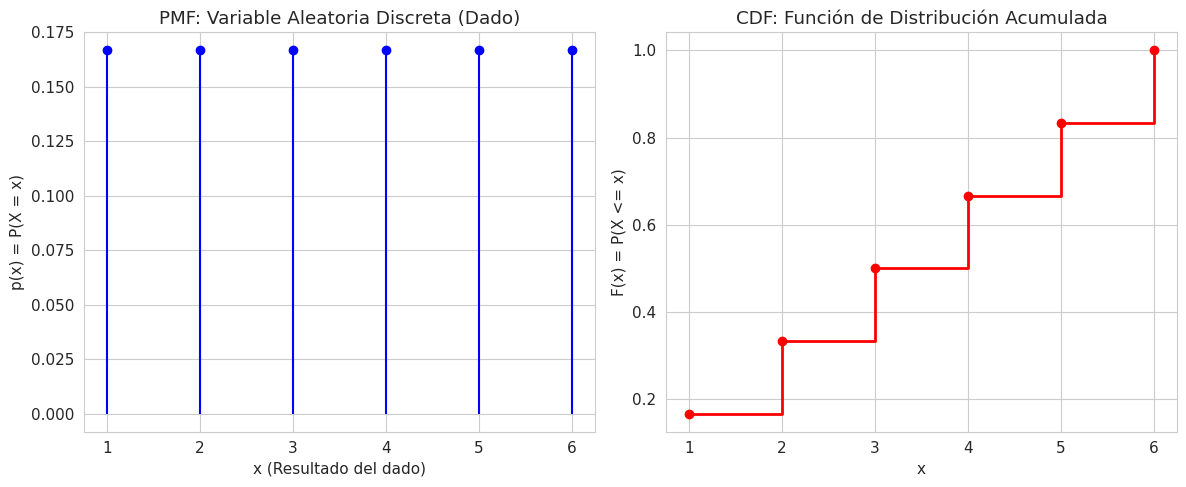

a) P(X = 4) = 0.1667
b) P(X <= 3) = 0.5000
c) P(2 <= X <= 5) = 0.6667


In [ ]:
#TAREA 2 = resultado del lanzamiento de un dado justo
x_valores = np.array([1, 2, 3, 4, 5, 6])
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
cdf_dado = np.cumsum(pmf_dado)

# Visualización de PMF y CDF
plt.figure(figsize=(12, 5))

# Subplot 1: PMF
plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')

# Subplot 2: CDF
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Función de Distribución Acumulada')

plt.tight_layout()
plt.show()

# Cálculos de probabilidad
prob_4 = pmf_dado[x_valores == 4][0]
prob_menor_3 = cdf_dado[x_valores == 3][0]
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]

print(f"a) P(X = 4) = {prob_4:.4f}")
print(f"b) P(X <= 3) = {prob_menor_3:.4f}")
print(f"c) P(2 <= X <= 5) = {prob_entre_2_5:.4f}")

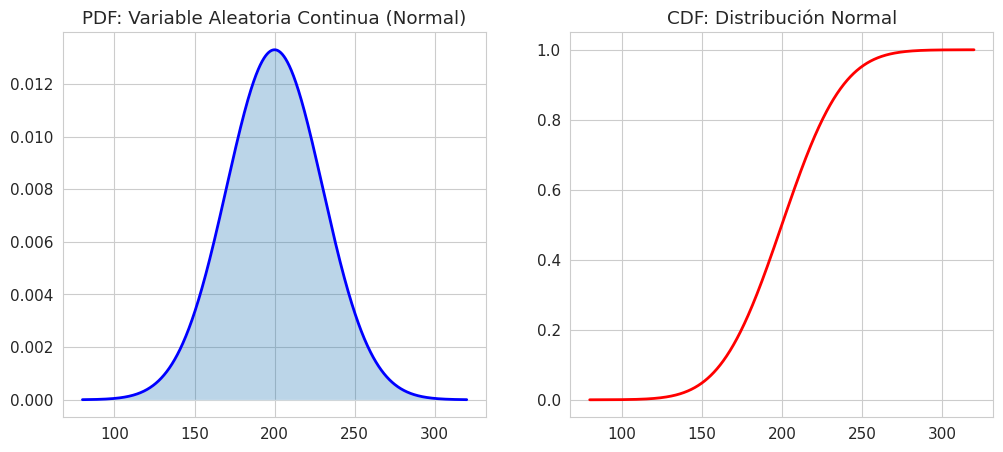

a) P(X <= 180) = 0.2525
b) P(X > 250) = 0.0478
c) P(170 <= X <= 230) = 0.6827
d) Percentil 95: 249.35 ms


In [ ]:
# TAREA 3: X = tiempo de respuesta de un servidor (ms)
mu, sigma = 200, 30
dist_normal = norm(loc=mu, scale=sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf_normal = dist_normal.pdf(x)

# Visualización
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.title('PDF: Variable Aleatoria Continua (Normal)')

plt.subplot(1, 2, 2)
plt.plot(x, dist_normal.cdf(x), 'r-', linewidth=2)
plt.title('CDF: Distribución Normal')
plt.show()

# Cálculos
print(f"a) P(X <= 180) = {dist_normal.cdf(180):.4f}")
print(f"b) P(X > 250) = {1 - dist_normal.cdf(250):.4f}")
print(f"c) P(170 <= X <= 230) = {dist_normal.cdf(230) - dist_normal.cdf(170):.4f}")
print(f"d) Percentil 95: {dist_normal.ppf(0.95):.2f} ms")

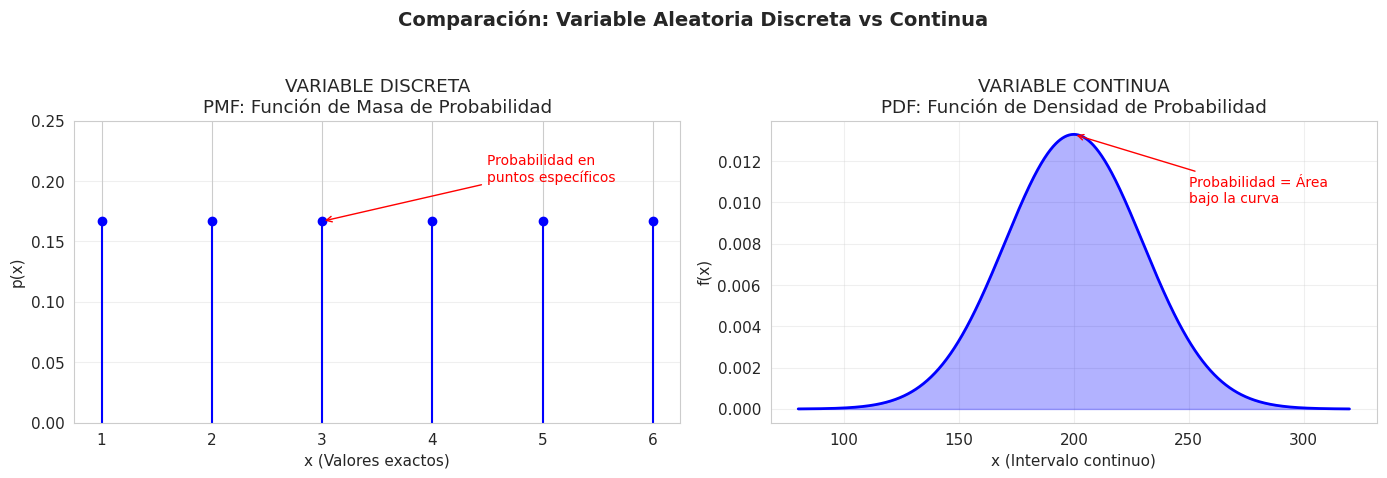

In [ ]:
# Tarea 4: Comparación Visual PMF vs PDF

# 1. Configuración de datos para la comparación
# Datos Discretos (Dado)
x_disc = np.array([1, 2, 3, 4, 5, 6])
pmf_disc = np.array([1/6] * 6)

# Datos Continuos (Normal: mu=200, sigma=30)
mu, sigma = 200, 30
x_cont = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf_cont = norm.pdf(x_cont, mu, sigma)

# 2. Creación de la visualización dual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Lado Izquierdo: VARIABLE DISCRETA ---
axes[0].stem(x_disc, pmf_disc, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x (Valores exactos)')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Función de Masa de Probabilidad')
axes[0].set_xticks(x_disc)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotación para la probabilidad puntual [cite: 73]
axes[0].annotate('Probabilidad en\npuntos específicos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# --- Lado Derecho: VARIABLE CONTINUA ---
axes[1].plot(x_cont, pdf_cont, 'b-', linewidth=2)
axes[1].fill_between(x_cont, pdf_cont, alpha=0.3, color='blue')
axes[1].set_xlabel('x (Intervalo continuo)')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Función de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotación para la probabilidad como área [cite: 74]
axes[1].annotate('Probabilidad = Área\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparación: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
#Tarea 5: Aplicacion - Variables Aleatorias en la UNL


# Plantilla para registro de variables identificadas en la UNL
variables_unl = [
    {
        'nombre': 'Libros prestados por día',
        'ubicacion': 'Biblioteca',
        'tipo': 'Discreta',
        'valores_posibles': '0, 1, 2, 3, ...',
        'distribucion_esperada': 'Poisson'
    },
    {
        'nombre': 'Tiempo de espera en caja',
        'ubicacion': 'Cafetería central',
        'tipo': 'Continua',
        'valores_posibles': '0 a 15 minutos',
        'distribucion_esperada': 'Exponencial'
    },
    {
        'nombre': 'Computadoras operativas',
        'ubicacion': 'Laboratorios de Computación',
        'tipo': 'Discreta',
        'valores_posibles': '0 a 30 computadoras',
        'distribucion_esperada': 'Binomial'
    },
    {
        'nombre': 'Tiempo de parqueo por vehículo',
        'ubicacion': 'Estacionamiento Facultades',
        'tipo': 'Continua',
        'valores_posibles': '0 a 8 horas',
        'distribucion_esperada': 'Normal'
    },
    {
        'nombre': 'Estudiantes con retraso',
        'ubicacion': 'Aulas de clase',
        'tipo': 'Discreta',
        'valores_posibles': '0 a 40 estudiantes',
        'distribucion_esperada': 'Poisson'
    }
]

# Mostrar en formato de tabla profesional
df = pd.DataFrame(variables_unl)
print("TABLA DE REGISTRO DE VARIABLES ALEATORIAS - CAMPUS UNL")
print("-" * 60)
print(df.to_string(index=False))

TABLA DE REGISTRO DE VARIABLES ALEATORIAS - CAMPUS UNL
------------------------------------------------------------
                        nombre                   ubicacion     tipo    valores_posibles distribucion_esperada
      Libros prestados por día                  Biblioteca Discreta     0, 1, 2, 3, ...               Poisson
      Tiempo de espera en caja           Cafetería central Continua      0 a 15 minutos           Exponencial
       Computadoras operativas Laboratorios de Computación Discreta 0 a 30 computadoras              Binomial
Tiempo de parqueo por vehículo  Estacionamiento Facultades Continua         0 a 8 horas                Normal
       Estudiantes con retraso              Aulas de clase Discreta  0 a 40 estudiantes               Poisson


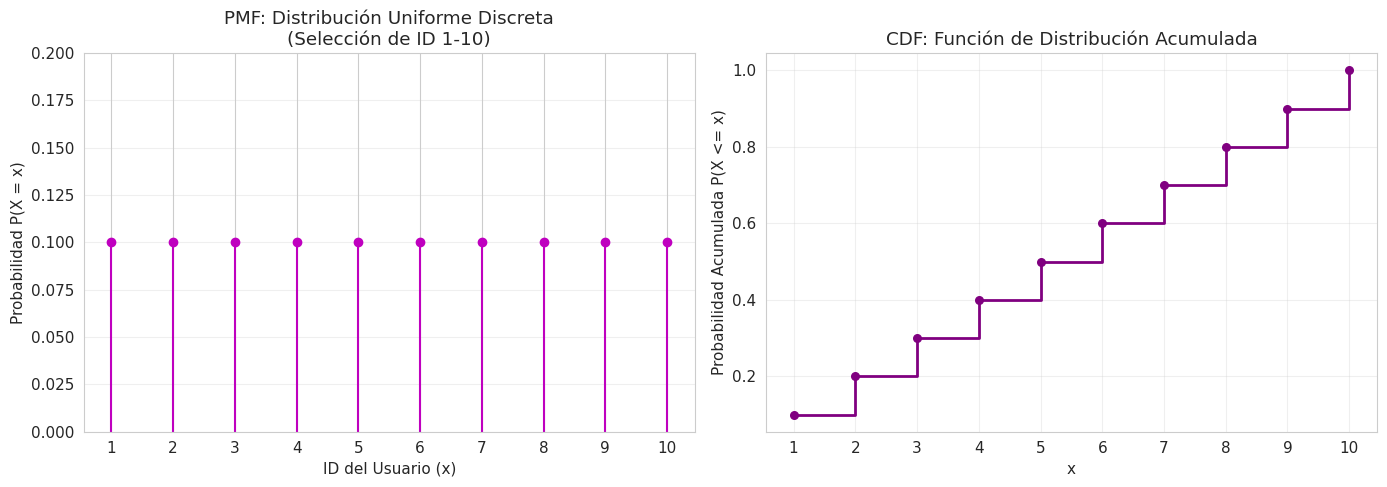

--- CÁLCULOS ESTADÍSTICOS (FASE 3 - OPCIÓN B) ---
1. P(X = 7): 0.1000 (Equivale a 1/10)
2. P(X <= 4): 0.4000
3. P(3 <= X <= 8): 0.6000


In [ ]:
# =================================================================
# FASE 3: TRABAJO AUTÓNOMO - DISTRIBUCIÓN UNIFORME DISCRETA
# =================================================================
# Contexto: Selección al azar de un ID de usuario en un sistema
# de pruebas que contiene IDs del 1 al 10.


# 1. Definición de parámetros (IDs del 1 al 10)
bajo, alto = 1, 11  # En scipy, el límite superior es exclusivo [bajo, alto-1]
dist_uniforme = randint(bajo, alto)
x = np.arange(bajo, alto)

# 2. Generar funciones estadísticas
pmf_uni = dist_uniforme.pmf(x)
cdf_uni = dist_uniforme.cdf(x)

# 3. Visualización
plt.figure(figsize=(14, 5))

# Gráfico de PMF (Masa)
plt.subplot(1, 2, 1)
plt.stem(x, pmf_uni, basefmt=" ", linefmt='m-', markerfmt='mo', label='PMF Uniforme')
plt.title('PMF: Distribución Uniforme Discreta\n(Selección de ID 1-10)')
plt.xlabel('ID del Usuario (x)')
plt.ylabel('Probabilidad P(X = x)')
plt.xticks(x)
plt.ylim(0, 0.2)
plt.grid(axis='y', alpha=0.3)

# Gráfico de CDF (Acumulada)
plt.subplot(1, 2, 2)
plt.step(x, cdf_uni, where='post', color='purple', linewidth=2, label='CDF Uniforme')
plt.scatter(x, cdf_uni, color='purple', s=30)
plt.title('CDF: Función de Distribución Acumulada')
plt.xlabel('x')
plt.ylabel('Probabilidad Acumulada P(X <= x)')
plt.xticks(x)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Cálculo de Probabilidades Específicas
print("--- CÁLCULOS ESTADÍSTICOS (FASE 3 - OPCIÓN B) ---")

# a) P(X = 7): Probabilidad de elegir exactamente el ID 7
p_exacto_7 = dist_uniforme.pmf(7)
print(f"1. P(X = 7): {p_exacto_7:.4f} (Equivale a 1/10)")

# b) P(X <= 4): Probabilidad de elegir un ID entre 1 y 4
p_menor_4 = dist_uniforme.cdf(4)
print(f"2. P(X <= 4): {p_menor_4:.4f}")

# c) P(3 <= X <= 8): Probabilidad de elegir un ID en el rango [3, 8]
p_rango = dist_uniforme.cdf(8) - dist_uniforme.cdf(2)
print(f"3. P(3 <= X <= 8): {p_rango:.4f}")

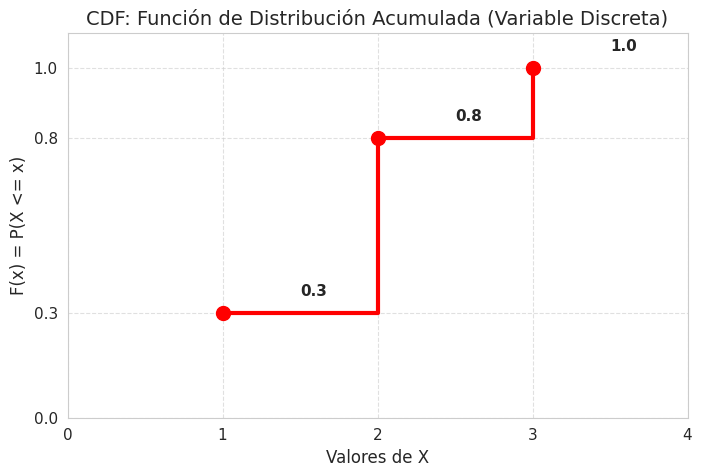

In [2]:
# Dibuje aproximadamente la CDF de una variable
#discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.
import matplotlib.pyplot as plt
import numpy as np

# Datos del problema
x_puntos = [1, 2, 3]
probabilidades = [0.3, 0.5, 0.2]
cdf_valores = np.cumsum(probabilidades)

# Configuración de la gráfica
plt.figure(figsize=(8, 5))
# Dibujamos los escalones
plt.step(x_puntos, cdf_valores, where='post', color='red', linewidth=3, label='CDF F(x)')

# Añadimos puntos para marcar los saltos
plt.scatter(x_puntos, cdf_valores, color='red', s=100, zorder=5)

# Detalles estéticos
plt.title('CDF: Función de Distribución Acumulada (Variable Discreta)', fontsize=14)
plt.xlabel('Valores de X', fontsize=12)
plt.ylabel('F(x) = P(X <= x)', fontsize=12)
plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 0.3, 0.8, 1.0])
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.1)
plt.xlim(0, 4)

# Anotaciones de los niveles
plt.annotate('0.3', xy=(1.5, 0.3), xytext=(1.5, 0.35), fontweight='bold')
plt.annotate('0.8', xy=(2.5, 0.8), xytext=(2.5, 0.85), fontweight='bold')
plt.annotate('1.0', xy=(3.5, 1.0), xytext=(3.5, 1.05), fontweight='bold')

plt.show()